In [61]:
import pandas as pd
import numpy as np

## Load cleaned dataset

In [20]:
df=pd.read_csv("cleaned_housing.csv")

## One hot encoding

In [22]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'livingArea', 'lotSize', 'yearBuilt',
       'propertyTaxRate', 'taxAssessedValue', 'zestimate', 'rentZestimate',
       'latitude', 'longitude', 'resoFacts/stories', 'resoFacts/hasGarage',
       'resoFacts/hasHeating', 'resoFacts/hasCooling',
       'resoFacts/hasFireplace', 'resoFacts/isNewConstruction', 'homeType'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25731 entries, 0 to 25730
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price                        25731 non-null  int64  
 1   bedrooms                     25731 non-null  float64
 2   bathrooms                    25731 non-null  float64
 3   livingArea                   25731 non-null  float64
 4   lotSize                      25731 non-null  float64
 5   yearBuilt                    25731 non-null  float64
 6   propertyTaxRate              25731 non-null  float64
 7   taxAssessedValue             25731 non-null  float64
 8   zestimate                    25731 non-null  float64
 9   rentZestimate                25731 non-null  float64
 10  latitude                     25731 non-null  float64
 11  longitude                    25731 non-null  float64
 12  resoFacts/stories            25731 non-null  float64
 13  resoFacts/hasGar

In [25]:
df=pd.get_dummies(df,drop_first=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25731 entries, 0 to 25730
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price                        25731 non-null  int64  
 1   bedrooms                     25731 non-null  float64
 2   bathrooms                    25731 non-null  float64
 3   livingArea                   25731 non-null  float64
 4   lotSize                      25731 non-null  float64
 5   yearBuilt                    25731 non-null  float64
 6   propertyTaxRate              25731 non-null  float64
 7   taxAssessedValue             25731 non-null  float64
 8   zestimate                    25731 non-null  float64
 9   rentZestimate                25731 non-null  float64
 10  latitude                     25731 non-null  float64
 11  longitude                    25731 non-null  float64
 12  resoFacts/stories            25731 non-null  float64
 13  resoFacts/hasGar

In [46]:
df=df.astype(int)
df

,price,bedrooms,bathrooms,livingArea,lotSize,yearBuilt,propertyTaxRate,taxAssessedValue,zestimate,rentZestimate,...,resoFacts/stories,resoFacts/hasGarage,resoFacts/hasHeating,resoFacts/hasCooling,resoFacts/hasFireplace,resoFacts/isNewConstruction,homeType_CONDO,homeType_HOME_TYPE_UNKNOWN,homeType_SINGLE_FAMILY,homeType_TOWNHOUSE
0,315400,3,3,1806,1555,2007,1,273960,317406,1950,...,2,0,1,0,1,0,0,0,0,1
1,400000,3,3,1518,3484,2001,1,426330,573700,2545,...,2,0,1,1,1,0,0,0,1,0
2,512000,4,3,2724,9583,1982,1,397560,512355,1995,...,2,0,1,1,1,0,0,0,1,0
3,348000,3,1,1217,13939,1953,1,269520,573700,1695,...,1,0,1,0,1,0,0,0,1,0
4,510000,6,3,2400,8545,1967,1,421980,573700,1395,...,2,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25726,415000,3,2,1378,10018,1977,1,386050,489400,2495,...,1,0,1,1,1,0,0,0,1,0
25727,615000,4,3,2176,9583,1974,1,447330,725500,2495,...,3,0,1,1,1,0,0,0,1,0
25728,380000,2,2,1466,1742,2001,1,426330,387200,2131,...,2,1,1,1,1,0,0,0,0,1
25729,57997,3,2,1450,17859,1920,1,370770,563700,2564,...,2,0,1,0,0,0,0,0,1,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25731 entries, 0 to 25730
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   price                        25731 non-null  int64
 1   bedrooms                     25731 non-null  int64
 2   bathrooms                    25731 non-null  int64
 3   livingArea                   25731 non-null  int64
 4   lotSize                      25731 non-null  int64
 5   yearBuilt                    25731 non-null  int64
 6   propertyTaxRate              25731 non-null  int64
 7   taxAssessedValue             25731 non-null  int64
 8   zestimate                    25731 non-null  int64
 9   rentZestimate                25731 non-null  int64
 10  latitude                     25731 non-null  int64
 11  longitude                    25731 non-null  int64
 12  resoFacts/stories            25731 non-null  int64
 13  resoFacts/hasGarage          25731 non-null  i

## X and Y seperation

In [48]:
# X is features and Y is target col i.e.,price
X=df.drop("price",axis=1)
Y=df["price"]

## Train-Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## Model create and fit

In [69]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [56]:
Y_pred = model.predict(X_test)
Y_pred

array([403510.906756  , 384083.56896305, 161946.99116016, ...,
       362570.79387004, 636066.7319404 , 488933.50240244], shape=(5147,))

## Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)
print("MSE:", mse)
rsme = np.sqrt(mse)
print("RSME:", rsme)


MSE: 16223778047.714882
RSME: 127372.5953559669


In [60]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)
print("R2 Score:", r2)

R2 Score: 0.856492821624309


In [68]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_df)

                        Feature   Coefficient
0                      bedrooms -6.218850e+03
1                     bathrooms -5.356434e+02
2                    livingArea  4.759348e+01
3                       lotSize -8.142586e-04
4                     yearBuilt -1.113206e+02
5               propertyTaxRate -3.749347e+05
6              taxAssessedValue  3.880563e-02
7                     zestimate  7.517900e-01
8                 rentZestimate  1.035427e+01
9                      latitude  2.080924e-09
10                    longitude  9.143960e+03
11            resoFacts/stories -7.917465e+03
12          resoFacts/hasGarage  2.154091e+03
13         resoFacts/hasHeating -1.063376e+05
14         resoFacts/hasCooling  6.247498e+03
15       resoFacts/hasFireplace  1.740144e+03
16  resoFacts/isNewConstruction  2.294090e+04
17               homeType_CONDO -3.059539e+05
18   homeType_HOME_TYPE_UNKNOWN -4.425747e+05
19       homeType_SINGLE_FAMILY -3.114999e+05
20           homeType_TOWNHOUSE -3

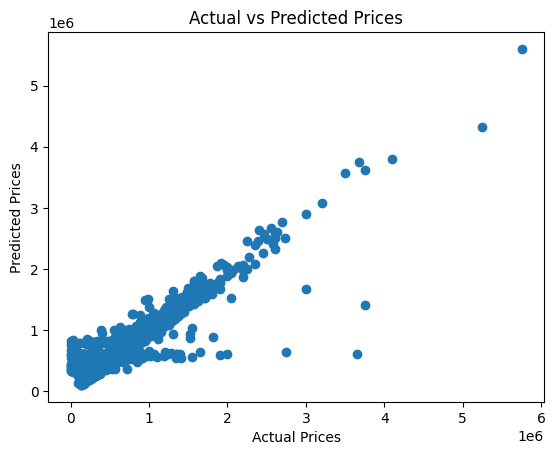

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

#most points following diagonal --> predictions are close to actual values
#some shows outliers(high prices)

In [73]:
train_score = model.score(X_train, Y_train)
test_score = model.score(X_test, Y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.4308477314748378
Test R2: 0.856492821624309
